In [4]:
import os
import shutil
import zipfile
from pathlib import Path

def locate_and_prepare_dataset():
    # 1. Check if student-mat.csv already exists in the current directory
    if os.path.exists('student-mat.csv'):
        print("Found student-mat.csv in current directory.")
        return 'student-mat.csv'
        
    print(f"Current working directory: {os.getcwd()}")
    print("Searching common folders (Current folder, Downloads, Documents, Desktop)...")
    
    search_dirs = [
        Path.cwd(),
        Path.home() / "Downloads",
        Path.home() / "Documents",
        Path.home() / "Desktop"
    ]
    
    # Check for direct CSV first
    for base_dir in search_dirs:
        for file in base_dir.rglob("student-mat.csv"):
            print(f"Found CSV at: {file}")
            shutil.copy(file, Path.cwd() / "student-mat.csv")
            print("Copied student-mat.csv to current working folder.")
            return 'student-mat.csv'
            
    # Check for zip archive if CSV wasn't found directly
    for base_dir in search_dirs:
        for zip_file in base_dir.rglob("*student*.zip"):
            print(f"Found archive at: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall(Path.cwd())
            # Handle nested zip if present
            if os.path.exists('student.zip'):
                with zipfile.ZipFile('student.zip', 'r') as inner_z:
                    inner_z.extractall(Path.cwd())
            if os.path.exists('student-mat.csv'):
                print("Successfully extracted student-mat.csv to current directory.")
                return 'student-mat.csv'
                
    print("\nCould not find student-mat.csv or student.zip automatically.")
    print("Please manually drag student-mat.csv (or student+performance.zip) into your VS Code left sidebar.")
    return None

data_file = locate_and_prepare_dataset()

Found student-mat.csv in current directory.


C:\Users\Dell\AppData\Local\Temp\ipykernel_12376\3987575119.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


Data successfully split:
Training samples: 316 students
Testing samples:  79 students

--- Stage 1: Exam Attendance / Zero Hurdle Classification ---
Classification Accuracy: 0.9620
                     precision    recall  f1-score   support

Zero Mark (Absence)       0.67      0.80      0.73         5
       Present (>0)       0.99      0.97      0.98        74

           accuracy                           0.96        79
          macro avg       0.83      0.89      0.85        79
       weighted avg       0.97      0.96      0.96        79

--- Two-Stage Hurdle Model Overall Performance ---
RMSE:     1.841
MAE:      1.006
R^2 Score: 0.835

--- Advanced Architecture Comparison ---
                           Model  RMSE   MAE  R^2 Score
 Standard Random Forest Baseline 1.941 1.179      0.816
      Two-Stage Hurdle (RF + RF) 1.841 1.006      0.835
Feedforward Neural Network (MLP) 2.681 1.914      0.649


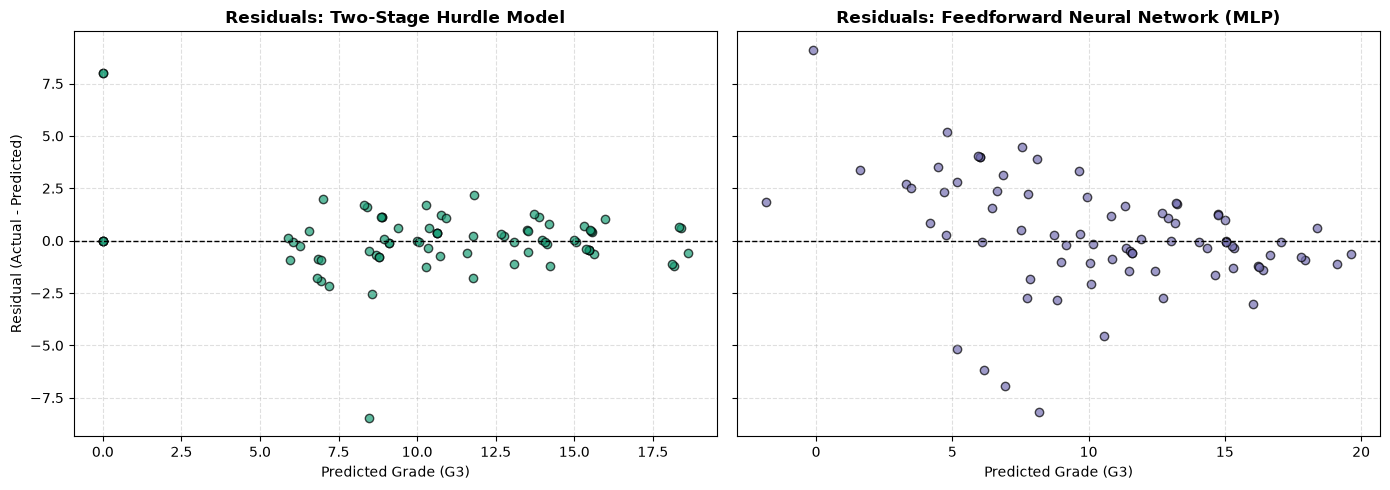

Plots saved to: images/advanced_models_residuals.png


In [5]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report

# ==============================================================================
# 1. ROBUST DATA LOADING (Handles any working directory / zip archive)
# ==============================================================================
def find_or_extract_data():
    candidate_paths = [
        'student-mat.csv',
        'data/student-mat.csv',
        '../data/student-mat.csv',
        './student-mat.csv'
    ]
    for p in candidate_paths:
        if os.path.exists(p):
            return p

    # If CSV not found directly, check for zip archives and extract
    zip_candidates = ['student+performance.zip', 'student.zip', '../student+performance.zip']
    for z in zip_candidates:
        if os.path.exists(z):
            with zipfile.ZipFile(z, 'r') as zip_ref:
                zip_ref.extractall('.')
            # student.zip might be nested inside
            if os.path.exists('student.zip') and not os.path.exists('student-mat.csv'):
                with zipfile.ZipFile('student.zip', 'r') as inner_zip:
                    inner_zip.extractall('.')
            if os.path.exists('student-mat.csv'):
                return 'student-mat.csv'

    raise FileNotFoundError("Could not find 'student-mat.csv'. Ensure the file is in your project directory.")

data_path = find_or_extract_data()
df = pd.read_csv(data_path, sep=';')

# Create images folder safely in local directory
os.makedirs('images', exist_ok=True)

# ==============================================================================
# 2. FEATURE / TARGET PREPARATION & TRAIN-TEST SPLIT
# ==============================================================================
X = df.drop(columns=['G3'])
y = df['G3']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Convert y_test to a numpy array to ensure clean positional indexing
y_test_arr = y_test.values

print(f"Data successfully split:")
print(f"Training samples: {X_train.shape[0]} students")
print(f"Testing samples:  {X_test.shape[0]} students\n")

# ==============================================================================
# 3. BASELINE: STANDARD RANDOM FOREST REGRESSOR
# ==============================================================================
rf_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42))
])
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test_arr, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test_arr, y_pred_baseline)
r2_baseline = r2_score(y_test_arr, y_pred_baseline)

# ==============================================================================
# 4. TWO-STAGE HURDLE MODEL
# ==============================================================================
# Stage 1: Binary hurdle target (0 = zero/absence, 1 = sat exam)
z_train = (y_train > 0).astype(int)
z_test = (y_test > 0).astype(int)

# Fit Stage 1 Classifier with balanced class weights for rare zero-mark cases
hurdle_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        class_weight='balanced', 
        random_state=42
    ))
])
hurdle_clf.fit(X_train, z_train)
z_pred = hurdle_clf.predict(X_test)

print("--- Stage 1: Exam Attendance / Zero Hurdle Classification ---")
print(f"Classification Accuracy: {accuracy_score(z_test, z_pred):.4f}")
print(classification_report(z_test, z_pred, target_names=['Zero Mark (Absence)', 'Present (>0)']))

# Stage 2: Regressor fitted strictly on students who scored > 0
mask_train = (y_train > 0)
X_train_present = X_train[mask_train]
y_train_present = y_train[mask_train]

hurdle_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42))
])
hurdle_reg.fit(X_train_present, y_train_present)

# Combined Hurdle Prediction
y_pred_hurdle = np.zeros(len(y_test_arr), dtype=float)
present_indices = np.where(z_pred == 1)[0]
if len(present_indices) > 0:
    y_pred_hurdle[present_indices] = hurdle_reg.predict(X_test.iloc[present_indices])

rmse_hurdle = np.sqrt(mean_squared_error(y_test_arr, y_pred_hurdle))
mae_hurdle = mean_absolute_error(y_test_arr, y_pred_hurdle)
r2_hurdle = r2_score(y_test_arr, y_pred_hurdle)

print("--- Two-Stage Hurdle Model Overall Performance ---")
print(f"RMSE:     {rmse_hurdle:.3f}")
print(f"MAE:      {mae_hurdle:.3f}")
print(f"R^2 Score: {r2_hurdle:.3f}\n")

# ==============================================================================
# 5. FEEDFORWARD NEURAL NETWORK (MLP) WITH TARGET NORMALIZATION
# ==============================================================================
mlp_base = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.05,
    learning_rate_init=0.005,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)

# Wrapping in TransformedTargetRegressor prevents exploding gradients / matmul overflow
mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('mlp', TransformedTargetRegressor(regressor=mlp_base, transformer=StandardScaler()))
])

mlp_pipeline.fit(X_train, y_train)
y_pred_mlp = mlp_pipeline.predict(X_test)

rmse_mlp = np.sqrt(mean_squared_error(y_test_arr, y_pred_mlp))
mae_mlp = mean_absolute_error(y_test_arr, y_pred_mlp)
r2_mlp = r2_score(y_test_arr, y_pred_mlp)

# ==============================================================================
# 6. ARCHITECTURE COMPARISON TABLE
# ==============================================================================
advanced_results = pd.DataFrame([
    {"Model": "Standard Random Forest Baseline", "RMSE": round(rmse_baseline, 3), "MAE": round(mae_baseline, 3), "R^2 Score": round(r2_baseline, 3)},
    {"Model": "Two-Stage Hurdle (RF + RF)", "RMSE": round(rmse_hurdle, 3), "MAE": round(mae_hurdle, 3), "R^2 Score": round(r2_hurdle, 3)},
    {"Model": "Feedforward Neural Network (MLP)", "RMSE": round(rmse_mlp, 3), "MAE": round(mae_mlp, 3), "R^2 Score": round(r2_mlp, 3)}
])

print("--- Advanced Architecture Comparison ---")
print(advanced_results.to_string(index=False))

# ==============================================================================
# 7. RESIDUAL DIAGNOSTICS PLOTS
# ==============================================================================
residuals_hurdle = y_test_arr - y_pred_hurdle
residuals_mlp = y_test_arr - y_pred_mlp

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Hurdle Residuals
axes[0].scatter(y_pred_hurdle, residuals_hurdle, color='#1b9e77', edgecolor='black', alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title("Residuals: Two-Stage Hurdle Model", fontweight='bold')
axes[0].set_xlabel("Predicted Grade (G3)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].grid(True, linestyle='--', alpha=0.4)

# MLP Residuals
axes[1].scatter(y_pred_mlp, residuals_mlp, color='#7570b3', edgecolor='black', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Residuals: Feedforward Neural Network (MLP)", fontweight='bold')
axes[1].set_xlabel("Predicted Grade (G3)")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('images/advanced_models_residuals.png', dpi=300)
plt.show()
print("Plots saved to: images/advanced_models_residuals.png")